<a href="https://colab.research.google.com/github/dilp90/PpIA_FIME_UANL/blob/main/Ejercicios/Ejercicio1_PpIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicio 1.1.- Limpieza y Manipulación con Pandas**

Objetivo: Cargar los datos, entender su estructura y realizar filtrados básicos.

Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Importa el dataset directamente desde una URL.

In [3]:
# Cargar dataset real (Vino tinto)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("¡Dataset cargado con éxito!")

¡Dataset cargado con éxito!


2. Muestra las primeras 5 filas y el resumen estadístico (describe()).

In [5]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


3. Identifica si existen valores nulos y elimínalos.

In [7]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


4. Crea una nueva columna llamada is_good que sea 1 si la quality es mayor a 6, y 0 en caso contrario.

In [8]:
df['is_good'] = np.where(df['quality'] > 6, 1, 0)
print("DataFrame con la nueva columna 'is_good':")
display(df.head())

DataFrame con la nueva columna 'is_good':


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


5. Filtra el DataFrame para mostrar solo los vinos con un nivel de alcohol superior al 11%

In [9]:
df_AlcoholSuperior = df[df['alcohol'] > 11]

In [10]:
df_AlcoholSuperior.shape

(408, 13)

# **Ejercicio 1.2.- Operaciones Matemáticas con NumPy**

Objetivo: Convertir los datos a matrices y realizar cálculos de bajo nivel que la IA necesita.

1. Convierte las columnas de características (features) en una matriz de NumPy llamada X.

In [11]:
X = df.drop(columns=['quality', 'is_good']).values
print("Forma de X:", X.shape)
print("Primeras 5 filas de X:\n", X[:5])

Forma de X: (1599, 11)
Primeras 5 filas de X:
 [[7.400e+00 7.000e-01 0.000e+00 1.900e+00 7.600e-02 1.100e+01 3.400e+01
  9.978e-01 3.510e+00 5.600e-01 9.400e+00]
 [7.800e+00 8.800e-01 0.000e+00 2.600e+00 9.800e-02 2.500e+01 6.700e+01
  9.968e-01 3.200e+00 6.800e-01 9.800e+00]
 [7.800e+00 7.600e-01 4.000e-02 2.300e+00 9.200e-02 1.500e+01 5.400e+01
  9.970e-01 3.260e+00 6.500e-01 9.800e+00]
 [1.120e+01 2.800e-01 5.600e-01 1.900e+00 7.500e-02 1.700e+01 6.000e+01
  9.980e-01 3.160e+00 5.800e-01 9.800e+00]
 [7.400e+00 7.000e-01 0.000e+00 1.900e+00 7.600e-02 1.100e+01 3.400e+01
  9.978e-01 3.510e+00 5.600e-01 9.400e+00]]


2. Calcula la media y la desviación estándar de cada columna utilizando únicamente funciones de NumPy (np.mean, np.std).

In [12]:
mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)

print("Media de cada columna de X:\n", mean_X)
print("Desviación estándar de cada columna de X:\n", std_X)

Media de cada columna de X:
 [ 8.31963727  0.52782051  0.27097561  2.5388055   0.08746654 15.87492183
 46.46779237  0.99674668  3.3111132   0.65814884 10.42298311]
Desviación estándar de cada columna de X:
 [1.74055180e+00 1.79003704e-01 1.94740214e-01 1.40948711e+00
 4.70505826e-02 1.04568856e+01 3.28850367e+01 1.88674370e-03
 1.54338181e-01 1.69453967e-01 1.06533430e+00]


Cuando utilizas `axis=0` en funciones de NumPy como `np.mean` o `np.std`, le estás indicando a la función que realice la operación a lo largo del eje de las filas, es decir, que *calcule* el resultado para cada columna. Imagina una tabla; axis=0 significa que las operaciones se realizan "hacia abajo" por cada columna.

3. **Normalización Z-Score:** Implementa manualmente la fórmula para normalizar los datos:

$$z = \frac{x - \mu}{\sigma}$$

Donde $x$ es el valor original, $\mu$ la media y $\sigma$ la desviación estándar.

In [13]:
X_normalized = (X - mean_X) / std_X
print("Primeras 5 filas de X normalizada:\n", X_normalized[:5])

Primeras 5 filas de X normalizada:
 [[-0.52835961  0.96187667 -1.39147228 -0.45321841 -0.24370669 -0.46619252
  -0.37913269  0.55827446  1.28864292 -0.57920652 -0.96024611]
 [-0.29854743  1.96744245 -1.39147228  0.04341614  0.2238752   0.87263823
   0.62436323  0.02826077 -0.7199333   0.1289504  -0.58477711]
 [-0.29854743  1.29706527 -1.18607043 -0.16942723  0.09635286 -0.08366945
   0.22904665  0.13426351 -0.33117661 -0.04808883 -0.58477711]
 [ 1.65485608 -1.38444349  1.4841536  -0.45321841 -0.26496041  0.10759209
   0.41150046  0.6642772  -0.97910442 -0.46118037 -0.58477711]
 [-0.52835961  0.96187667 -1.39147228 -0.45321841 -0.24370669 -0.46619252
  -0.37913269  0.55827446  1.28864292 -0.57920652 -0.96024611]]


# **Ejercicio 1.3.- Visualización de Insights con Matplotlib**

Objetivo: Comunicar visualmente las correlaciones y distribuciones de los datos.

1. Histograma: Crea un histograma de la variable alcohol para ver su distribución.

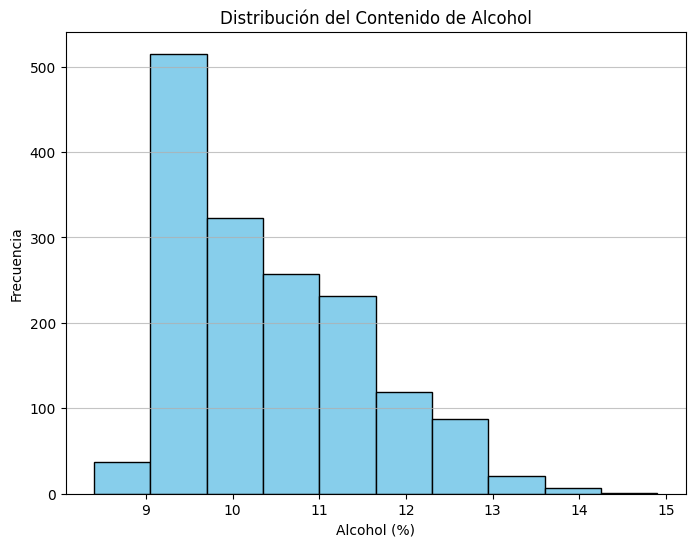

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(df['alcohol'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribución del Contenido de Alcohol')
plt.xlabel('Alcohol (%)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

2. Scatter Plot: Realiza un gráfico de dispersión entre pH y fixed acidity. ¿Notas alguna tendencia?

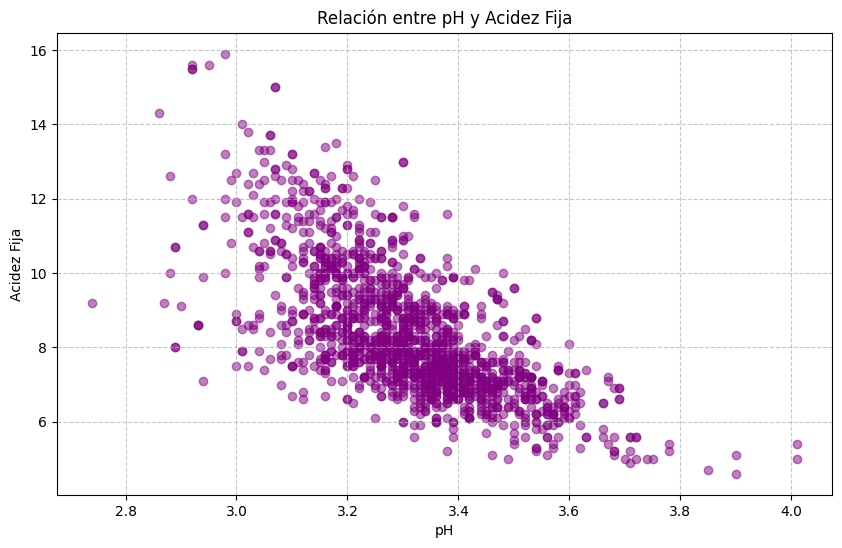

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['pH'], df['fixed acidity'], alpha=0.5, color='purple')
plt.title('Relación entre pH y Acidez Fija')
plt.xlabel('pH')
plt.ylabel('Acidez Fija')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

3. Boxplot: Genera un gráfico de cajas que compare el nivel de alcohol según el valor de la columna quality.

/tmp/ipykernel_1483/3610938554.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['alcohol'][df['quality'] == q] for q in sorted(df['quality'].unique())], labels=sorted(df['quality'].unique()))


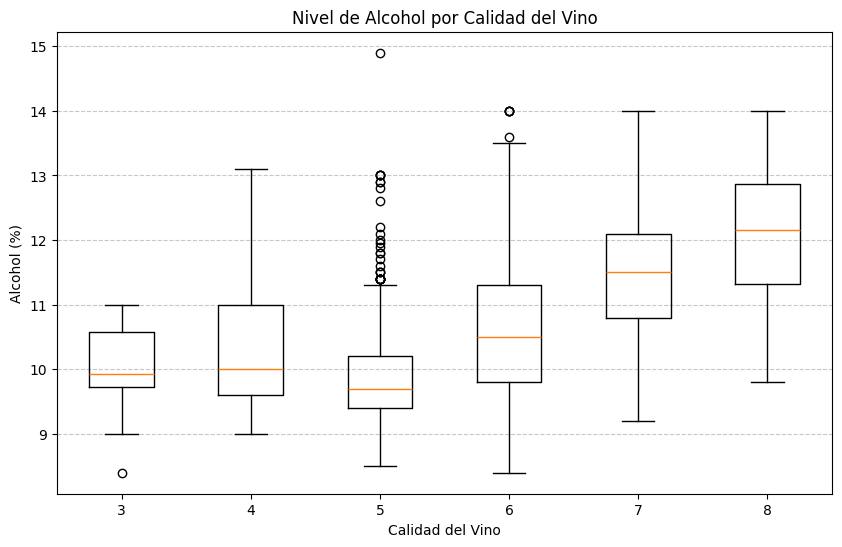

In [16]:
plt.figure(figsize=(10, 6))
plt.boxplot([df['alcohol'][df['quality'] == q] for q in sorted(df['quality'].unique())], labels=sorted(df['quality'].unique()))
plt.title('Nivel de Alcohol por Calidad del Vino')
plt.xlabel('Calidad del Vino')
plt.ylabel('Alcohol (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()